# ASAP8 somatic depth analysis — remote-focus calibrated

This notebook replaces note-based imaging depth with the **actual SLAP2 remote-focus position stored in the first DMD metadata acquisition for each session**.

Primary recorded-neuron depth is

\[
\mathrm{depth\ below\ pia}
=
\mathrm{remoteFocusPosition}_{\mu m}
-
\mathrm{pia\ remote\ focus}_{\mu m}.
\]

The requested pia references are:

- **DMD1:** −200.0 µm
- **DMD2:** −192.5 µm

The session-registry values are retained as `notes_depth_um` for comparison only. All primary recorded-neuron depth groups and recorded+SWC depth analyses use the remote-focus-derived values.

For multi-epoch sessions, only the **first/earliest DMD1 `.meta` file and first/earliest DMD2 `.meta` file** are used.

SWC reconstruction Z depths are included unchanged and are assumed to already be positive depth from pia.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import re
import warnings
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from IPython.display import display

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.dataset import (
    build_voltage_session_table,
    build_voltage_roi_table,
)

from vip_slap2_analysis.utils.utils import save_figure

SAVEPATH = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\superstack'

## Configuration

In [2]:
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

TARGET_MICE = [852835, 863774]
TARGET_SESSION_LABELS = None
TARGET_SESSION_IDS = None
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

TRACE_VARIANT = "dff_robust_f0_trial"
REGISTRATION_FILENAME = "roi_identity_registration.csv"
EXCLUDE_INVALID_ROIS = True
EXPECTED_F0_SMOOTH_SEC = 60.0

# User-specified remote-focus values corresponding to pia.
# These are authoritative for the conversion below.
PIA_REMOTE_FOCUS_UM = {
    1: -200.0,
    2: -192.5,
}

# Morphology reconstruction population used in the previous depth notebook.
SWC_DIR = Path(
    r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"
    r"\ASAP7\852841\852841_2026-08-01_16-17-34"
    r"\852841_2026-08-01_16-17-34"
    r"\slap2\dynamic_data\reference_stack"
    r"\super_stack_qc\full_reference_merge\Reconstructions"
)

DEPTH_GROUP_ORDER = ["<100 µm", "100–150 µm", ">150 µm"]
DEPTH_NAMES = {
    "<100 µm": "superficial",
    "100–150 µm": "middle",
    ">150 µm": "deep",
}
DEPTH_COLORS = {
    "<100 µm": "#EBA287",
    "100–150 µm": "#d1e2b0",
    ">150 µm": "#7bbcd5",
}

BIN_WIDTH_UM = 10.0


def depth_group_from_um(depth):
    depth = float(depth)
    if depth < 100:
        return "<100 µm"
    if depth <= 150:
        return "100–150 µm"
    return ">150 µm"

## Load the admitted ASAP8 sessions and note-based ROI registry

The registry depth is kept as the comparison estimate. The next section resolves `asset.session_dir`, finds the first DMD metadata acquisition, and derives the actual plane depth.

In [3]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

sessions = build_voltage_session_table(
    registry,
    subject_ids=TARGET_MICE,
    paradigms=PARADIGMS,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    session_labels=TARGET_SESSION_LABELS,
    session_ids=TARGET_SESSION_IDS,
    trace_variant=TRACE_VARIANT,
    expected_f0_smooth_sec=EXPECTED_F0_SMOOTH_SEC,
)

# Resolve asset.session_dir for the same sessions.
raw_sessions = registry.sessions(
    subject_ids=TARGET_MICE,
    paradigms=PARADIGMS,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
).copy()

asset_map = {}
for _, row in raw_sessions.iterrows():
    try:
        asset = registry.resolve_assets(row)
        asset_map[str(asset.session_id)] = asset
    except Exception as exc:
        warnings.warn(
            f"Could not resolve assets for {row.get('session_id', 'unknown')}: {exc}"
        )

sessions["session_id"] = sessions["session_id"].astype(str)
sessions["session_dir"] = sessions["session_id"].map(
    lambda sid: Path(asset_map[sid].session_dir) if sid in asset_map else None
)

rois = build_voltage_roi_table(
    sessions,
    registration_filename=REGISTRATION_FILENAME,
    exclude_invalid_rois=EXCLUDE_INVALID_ROIS,
)

print(f"{len(sessions)} sessions")
print(f"{rois['included'].sum()} / {len(rois)} ROI observations included")

display(
    sessions[[
        "subject_id", "session_id", "session_label", "session_order",
        "dmd1_depth_um", "dmd2_depth_um", "session_dir",
    ]]
)

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\voltage\dataset.py:203: UserWarning: 852835_2026-07-24_12-13-41: F0 smoother is 10 s, expected 60 s
  warnings.warn(


13 sessions
99 / 105 ROI observations included


,subject_id,session_id,session_label,session_order,dmd1_depth_um,dmd2_depth_um,session_dir
0,852835,852835_2026-07-23_14-27-27,A0,0,46.75,120.50,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,852835,852835_2026-07-24_12-13-41,A1,1,51.00,125.50,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,852835,852835_2026-07-27_11-59-54,A2,2,60.50,133.00,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,852835,852835_2026-07-28_17-13-56,B0,3,52.75,125.62,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,852835,852835_2026-07-29_10-08-37,B1,4,60.00,133.25,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,852835,852835_2026-07-30_15-04-34,B2,5,57.88,128.62,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,852835,852835_2026-08-01_14-58-35,G1,6,60.75,104.38,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,863774,863774_2026-08-04_08-12-47,A0,0,190.38,109.62,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,863774,863774_2026-08-05_13-17-41,A1,1,197.88,120.00,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,863774,863774_2026-08-06_09-15-41,A2,2,199.88,121.62,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


## Read actual remote focus from the first DMD metadata file

The `.meta` files are MATLAB 7.3/HDF5 files. The plane position is read from `remoteFocusPosition_um` and cross-checked against `AcquisitionContainer/ParsePlan/zs`.

Candidate files are ordered by the acquisition clock embedded in the filename so multi-epoch sessions deterministically use the earliest DMD1 and DMD2 acquisitions.

In [4]:
def _acquisition_clock_from_name(path):
    # Handles:
    #   acquisition_123250_DMD1.meta
    #   acquisition_20260727_123250_DMD1.meta
    name = Path(path).name
    m = re.search(
        r"acquisition_(?:\d{8}_)?(\d{6})_DMD[12]\.meta$",
        name,
        flags=re.I,
    )
    return int(m.group(1)) if m else 10**9


def find_first_dmd_meta(session_dir, dmd):
    session_dir = Path(session_dir)
    candidates = list(session_dir.rglob(f"*DMD{int(dmd)}.meta"))

    if not candidates:
        return None, []

    # Prefer the reorganized raw acquisition location used elsewhere in this repo.
    dynamic_candidates = [
        p for p in candidates
        if any(part.lower() == "dynamic_data" for part in p.parts)
    ]
    if dynamic_candidates:
        candidates = dynamic_candidates

    candidates = sorted(
        candidates,
        key=lambda p: (
            _acquisition_clock_from_name(p),
            len(p.parts),
            str(p).lower(),
        ),
    )
    return candidates[0], candidates


def read_remote_focus_um(meta_path):
    meta_path = Path(meta_path)

    with h5py.File(meta_path, "r") as h5:
        if "remoteFocusPosition_um" not in h5:
            raise KeyError(f"{meta_path.name}: missing remoteFocusPosition_um")

        remote = float(
            np.asarray(h5["remoteFocusPosition_um"][()]).squeeze()
        )

        parse_z = np.nan
        if "AcquisitionContainer/ParsePlan/zs" in h5:
            parse_z = float(
                np.asarray(
                    h5["AcquisitionContainer/ParsePlan/zs"][()]
                ).squeeze()
            )

    if np.isfinite(parse_z) and not np.isclose(remote, parse_z, atol=1e-3):
        warnings.warn(
            f"{meta_path.name}: remoteFocusPosition_um={remote:.3f}, "
            f"ParsePlan/zs={parse_z:.3f}"
        )

    return remote, parse_z


def read_annotation_pia_um(meta_path):
    # Audit only. Annotation values do NOT drive the conversion.
    meta_path = Path(meta_path)
    annotation_path = meta_path.with_suffix(".annotation.json")

    if not annotation_path.exists():
        return np.nan, None

    try:
        with open(annotation_path, "r", encoding="utf-8") as f:
            annotation = json.load(f)
        value = annotation.get("pia_depth_on_remote_focus_um", np.nan)
        return float(value), annotation_path
    except Exception as exc:
        warnings.warn(f"Could not read {annotation_path.name}: {exc}")
        return np.nan, annotation_path


plane_rows = []

for session in sessions.itertuples(index=False):
    if session.session_dir is None:
        warnings.warn(f"{session.session_id}: no resolved session_dir")
        continue

    for dmd in (1, 2):
        meta_path, all_candidates = find_first_dmd_meta(session.session_dir, dmd)
        notes_depth_um = float(getattr(session, f"dmd{dmd}_depth_um", np.nan))

        base = {
            "subject_id": str(session.subject_id),
            "session_id": str(session.session_id),
            "session_label": str(session.session_label),
            "session_order": int(session.session_order),
            "dmd": int(dmd),
            "notes_depth_um": notes_depth_um,
            "pia_remote_focus_um": PIA_REMOTE_FOCUS_UM[dmd],
        }

        if meta_path is None:
            plane_rows.append({
                **base,
                "meta_path": None,
                "n_meta_candidates": 0,
                "remote_focus_um": np.nan,
                "parseplan_z_um": np.nan,
                "annotation_pia_um": np.nan,
                "remote_depth_um": np.nan,
                "remote_minus_notes_um": np.nan,
            })
            continue

        remote_focus_um, parseplan_z_um = read_remote_focus_um(meta_path)
        annotation_pia_um, _ = read_annotation_pia_um(meta_path)

        # Positive values extend deeper into cortex.
        remote_depth_um = remote_focus_um - PIA_REMOTE_FOCUS_UM[dmd]

        plane_rows.append({
            **base,
            "meta_path": meta_path,
            "n_meta_candidates": len(all_candidates),
            "remote_focus_um": remote_focus_um,
            "parseplan_z_um": parseplan_z_um,
            "annotation_pia_um": annotation_pia_um,
            "remote_depth_um": remote_depth_um,
            "remote_minus_notes_um": remote_depth_um - notes_depth_um,
        })

plane_depths = pd.DataFrame(plane_rows)

if plane_depths.empty:
    raise RuntimeError("No session × DMD metadata records were created.")

plane_depths["remote_depth_group"] = plane_depths["remote_depth_um"].map(
    lambda x: depth_group_from_um(x) if np.isfinite(x) else np.nan
)
plane_depths["notes_depth_group"] = plane_depths["notes_depth_um"].map(
    lambda x: depth_group_from_um(x) if np.isfinite(x) else np.nan
)

display(
    plane_depths.sort_values(
        ["subject_id", "session_order", "dmd"]
    )[[
        "subject_id", "session_label", "session_order", "session_id", "dmd",
        "n_meta_candidates", "meta_path",
        "remote_focus_um", "pia_remote_focus_um",
        "remote_depth_um", "notes_depth_um", "remote_minus_notes_um",
        "annotation_pia_um",
    ]]
)

missing = plane_depths["remote_depth_um"].isna().sum()
if missing:
    print(f"WARNING: {missing} session × DMD planes have no remote-focus depth.")

annotation_audit = plane_depths.dropna(subset=["annotation_pia_um"]).copy()
if len(annotation_audit):
    annotation_audit["annotation_minus_configured_pia_um"] = (
        annotation_audit["annotation_pia_um"]
        - annotation_audit["pia_remote_focus_um"]
    )
    print("\nAnnotation pia convention audit:")
    display(
        annotation_audit[[
            "subject_id", "session_label", "dmd",
            "annotation_pia_um", "pia_remote_focus_um",
            "annotation_minus_configured_pia_um",
        ]]
    )

,subject_id,session_label,session_order,session_id,dmd,n_meta_candidates,meta_path,remote_focus_um,pia_remote_focus_um,remote_depth_um,notes_depth_um,remote_minus_notes_um,annotation_pia_um
0,852835,A0,0,852835_2026-07-23_14-27-27,1,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-153.250,-200.0,46.750,46.75,0.000,-200.0
1,852835,A0,0,852835_2026-07-23_14-27-27,2,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-72.000,-192.5,120.500,120.50,0.000,-192.0
2,852835,A1,1,852835_2026-07-24_12-13-41,1,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-149.000,-200.0,51.000,51.00,0.000,-200.0
3,852835,A1,1,852835_2026-07-24_12-13-41,2,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-67.000,-192.5,125.500,125.50,0.000,-192.0
4,852835,A2,2,852835_2026-07-27_11-59-54,1,3,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-139.500,-200.0,60.500,60.50,0.000,-200.0
5,852835,A2,2,852835_2026-07-27_11-59-54,2,3,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-59.500,-192.5,133.000,133.00,0.000,-192.0
6,852835,B0,3,852835_2026-07-28_17-13-56,1,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-147.250,-200.0,52.750,52.75,0.000,NaN
7,852835,B0,3,852835_2026-07-28_17-13-56,2,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-66.875,-192.5,125.625,125.62,0.005,NaN
8,852835,B1,4,852835_2026-07-29_10-08-37,1,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-140.000,-200.0,60.000,60.00,0.000,-200.0
9,852835,B1,4,852835_2026-07-29_10-08-37,2,2,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,-59.250,-192.5,133.250,133.25,0.000,-192.0



Annotation pia convention audit:


,subject_id,session_label,dmd,annotation_pia_um,pia_remote_focus_um,annotation_minus_configured_pia_um
0,852835,A0,1,-200.0,-200.0,0.0
1,852835,A0,2,-192.0,-192.5,0.5
2,852835,A1,1,-200.0,-200.0,0.0
3,852835,A1,2,-192.0,-192.5,0.5
4,852835,A2,1,-200.0,-200.0,0.0
5,852835,A2,2,-192.0,-192.5,0.5
8,852835,B1,1,-200.0,-200.0,0.0
9,852835,B1,2,-192.0,-192.5,0.5
10,852835,B2,1,-200.0,-200.0,0.0
11,852835,B2,2,-192.0,-192.5,0.5


## Remote-focus plane depth across sessions

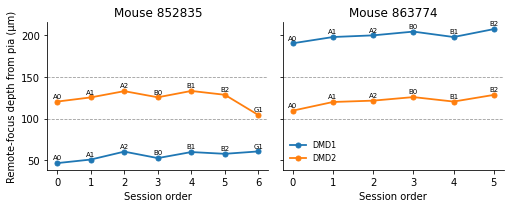

In [5]:
mice = sorted(plane_depths["subject_id"].unique())

fig, axs = plt.subplots(
    1,
    len(mice),
    figsize=(7.2, 3.0),
    sharey=True,
)
axs = np.atleast_1d(axs)

for ax, mouse in zip(axs, mice):
    m = plane_depths[
        (plane_depths["subject_id"] == mouse)
        & np.isfinite(plane_depths["remote_depth_um"])
    ].copy()

    for dmd, sub in m.groupby("dmd", observed=True):
        sub = sub.sort_values("session_order")
        ax.plot(
            sub["session_order"],
            sub["remote_depth_um"],
            "-o",
            lw=1.8,
            ms=5,
            label=f"DMD{dmd}",
        )

        for x, y, lab in zip(
            sub["session_order"], sub["remote_depth_um"], sub["session_label"]
        ):
            ax.text(x, y + 3, lab, ha="center", va="bottom", fontsize=7)

    ax.axhline(100, color="0.6", ls="--", lw=0.8)
    ax.axhline(150, color="0.6", ls="--", lw=0.8)
    ax.set_title(f"Mouse {mouse}")
    ax.set_xlabel("Session order")
    ax.spines[["top", "right"]].set_visible(False)

axs[0].set_ylabel("Remote-focus depth from pia (µm)")
axs[-1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

## Notes versus remote-focus depth

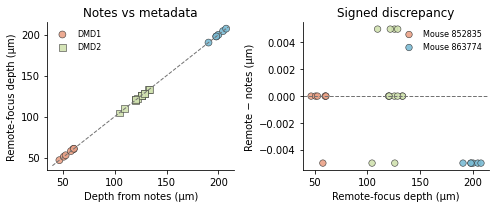

,subject_id,dmd,n_sessions,notes_depth_median_um,remote_depth_median_um,median_difference_um,min_difference_um,max_difference_um
0,852835,1,7,57.88,57.8750,0.000,-0.005,0.000
1,852835,2,7,125.62,125.6250,0.000,-0.005,0.005
2,863774,1,6,198.88,198.8750,-0.005,-0.005,-0.005
3,863774,2,6,121.06,121.0625,0.000,-0.005,0.005


In [6]:
valid_compare = plane_depths.dropna(
    subset=["notes_depth_um", "remote_depth_um"]
).copy()

fig, axs = plt.subplots(1, 2, figsize=(7.0, 3.0))

# Direct comparison.
ax = axs[0]
markers = {1: "o", 2: "s"}

for dmd, sub in valid_compare.groupby("dmd", observed=True):
    ax.scatter(
        sub["notes_depth_um"],
        sub["remote_depth_um"],
        s=48,
        marker=markers[dmd],
        c=[DEPTH_COLORS[g] for g in sub["remote_depth_group"]],
        edgecolor="0.2",
        linewidth=0.6,
        alpha=0.9,
        label=f"DMD{dmd}",
    )

lo = np.floor(
    min(valid_compare["notes_depth_um"].min(), valid_compare["remote_depth_um"].min())
    / 10
) * 10
hi = np.ceil(
    max(valid_compare["notes_depth_um"].max(), valid_compare["remote_depth_um"].max())
    / 10
) * 10

ax.plot([lo, hi], [lo, hi], "--", color="0.45", lw=1)
ax.set(
    xlim=(lo - 5, hi + 5),
    ylim=(lo - 5, hi + 5),
    xlabel="Depth from notes (µm)",
    ylabel="Remote-focus depth (µm)",
    title="Notes vs metadata",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8)

# Signed error.
ax = axs[1]
for mouse, sub in valid_compare.groupby("subject_id", observed=True):
    ax.scatter(
        sub["remote_depth_um"],
        sub["remote_minus_notes_um"],
        s=42,
        c=[DEPTH_COLORS[g] for g in sub["remote_depth_group"]],
        edgecolor="0.2",
        linewidth=0.6,
        alpha=0.9,
        label=f"Mouse {mouse}",
    )

ax.axhline(0, color="0.45", ls="--", lw=1)
ax.set(
    xlabel="Remote-focus depth (µm)",
    ylabel="Remote − notes (µm)",
    title="Signed discrepancy",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

# save_figure(fig,os.path.join(SAVEPATH,filen),formats=['.pdf'],dpi=300)

comparison_summary = (
    valid_compare
    .groupby(["subject_id", "dmd"], observed=True)
    .agg(
        n_sessions=("session_id", "nunique"),
        notes_depth_median_um=("notes_depth_um", "median"),
        remote_depth_median_um=("remote_depth_um", "median"),
        median_difference_um=("remote_minus_notes_um", "median"),
        min_difference_um=("remote_minus_notes_um", "min"),
        max_difference_um=("remote_minus_notes_um", "max"),
    )
    .reset_index()
)

display(comparison_summary)

## Attach remote-focus depth to every ROI observation

`notes_depth_um` preserves the registry estimate. From here onward, `depth_um` and `depth_group` are rebuilt from the remote-focus metadata.

No silent fallback to note depth is performed when a metadata plane is missing.

In [7]:
roi_depths = rois.copy()
roi_depths["session_id"] = roi_depths["session_id"].astype(str)
roi_depths["dmd"] = pd.to_numeric(
    roi_depths["dmd"], errors="raise"
).astype(int)

roi_depths["notes_depth_um"] = pd.to_numeric(
    roi_depths["depth_um"], errors="coerce"
)
roi_depths["notes_depth_group"] = roi_depths["notes_depth_um"].map(
    lambda x: depth_group_from_um(x) if np.isfinite(x) else np.nan
)

roi_depths = roi_depths.merge(
    plane_depths[[
        "session_id", "dmd", "meta_path",
        "remote_focus_um", "pia_remote_focus_um",
        "remote_depth_um", "remote_depth_group",
        "remote_minus_notes_um",
    ]],
    on=["session_id", "dmd"],
    how="left",
    validate="many_to_one",
)

# Primary depth columns now mean remote-focus-derived depth.
roi_depths["depth_um"] = roi_depths["remote_depth_um"]
roi_depths["depth_group"] = roi_depths["remote_depth_group"]

included_remote = (
    roi_depths["included"].astype(bool)
    & np.isfinite(roi_depths["remote_depth_um"])
)

print(
    "Included ROI observations with remote-focus depth: "
    f"{included_remote.sum()} / {roi_depths['included'].sum()}"
)

display(
    roi_depths.loc[included_remote, [
        "subject_id", "session_label", "session_id", "dmd", "roi",
        "cell_id", "notes_depth_um", "remote_depth_um",
        "remote_minus_notes_um", "depth_group",
    ]]
)

Included ROI observations with remote-focus depth: 99 / 99


,subject_id,session_label,session_id,dmd,roi,cell_id,notes_depth_um,remote_depth_um,remote_minus_notes_um,depth_group
0,852835,A0,852835_2026-07-23_14-27-27,1,0,852835_C003,46.75,46.750,0.000,<100 µm
1,852835,A0,852835_2026-07-23_14-27-27,1,1,852835_C002,46.75,46.750,0.000,<100 µm
2,852835,A0,852835_2026-07-23_14-27-27,1,2,852835_C001,46.75,46.750,0.000,<100 µm
3,852835,A0,852835_2026-07-23_14-27-27,1,3,852835_C000,46.75,46.750,0.000,<100 µm
4,852835,A0,852835_2026-07-23_14-27-27,2,0,852835_C006,120.50,120.500,0.000,100–150 µm
...,...,...,...,...,...,...,...,...,...,...
99,863774,B2,863774_2026-08-09_11-37-01,1,3,863774_C007,207.38,207.375,-0.005,>150 µm
100,863774,B2,863774_2026-08-09_11-37-01,2,0,863774_C003,128.50,128.500,0.000,100–150 µm
102,863774,B2,863774_2026-08-09_11-37-01,2,2,863774_C001,128.50,128.500,0.000,100–150 µm
103,863774,B2,863774_2026-08-09_11-37-01,2,3,863774_C004,128.50,128.500,0.000,100–150 µm


## Collapse longitudinal observations to one recorded neuron

For the anatomical distribution, each registered neuron contributes once. Its somatic depth is the **median remote-focus plane depth across sessions**. The across-session depth range is kept as QC.

In [8]:
roi_source = roi_depths[
    roi_depths["included"].astype(bool)
    & np.isfinite(roi_depths["remote_depth_um"])
].copy()

recorded_depths = (
    roi_source
    .groupby(["subject_id", "cell_id"], observed=True, as_index=False)
    .agg(
        soma_depth_um=("remote_depth_um", "median"),
        notes_soma_depth_um=("notes_depth_um", "median"),
        min_remote_depth_um=("remote_depth_um", "min"),
        max_remote_depth_um=("remote_depth_um", "max"),
        n_sessions=("session_id", "nunique"),
        n_roi_observations=("session_id", "size"),
        dmd=("dmd", "first"),
    )
)

recorded_depths["remote_depth_range_um"] = (
    recorded_depths["max_remote_depth_um"]
    - recorded_depths["min_remote_depth_um"]
)
recorded_depths["depth_group"] = recorded_depths["soma_depth_um"].map(
    depth_group_from_um
)
recorded_depths["notes_depth_group"] = recorded_depths[
    "notes_soma_depth_um"
].map(depth_group_from_um)
recorded_depths["depth_name"] = recorded_depths["depth_group"].map(DEPTH_NAMES)
recorded_depths["source"] = "Recorded ASAP8 ROI"
recorded_depths["neuron_id"] = (
    recorded_depths["subject_id"].astype(str)
    + ":"
    + recorded_depths["cell_id"].astype(str)
)

display(recorded_depths.sort_values(["subject_id", "soma_depth_um"]))

print("\nDepth-group counts using remote focus:")
display(
    recorded_depths
    .groupby(["subject_id", "depth_group"], observed=True)
    .size()
    .rename("n_cells")
    .reset_index()
)

print("\nDepth-group reassignment: notes → remote focus")
group_transition = pd.crosstab(
    recorded_depths["notes_depth_group"],
    recorded_depths["depth_group"],
    rownames=["Notes"],
    colnames=["Remote focus"],
    dropna=False,
)
display(group_transition)

changed_group = recorded_depths[
    recorded_depths["notes_depth_group"] != recorded_depths["depth_group"]
].copy()

print(f"Cells changing categorical depth group: {len(changed_group)}")
if len(changed_group):
    display(
        changed_group[[
            "subject_id", "cell_id", "dmd",
            "notes_soma_depth_um", "soma_depth_um",
            "notes_depth_group", "depth_group",
        ]]
    )

,subject_id,cell_id,soma_depth_um,notes_soma_depth_um,min_remote_depth_um,max_remote_depth_um,n_sessions,n_roi_observations,dmd,remote_depth_range_um,depth_group,notes_depth_group,depth_name,source,neuron_id
0,852835,852835_C000,57.8750,57.88,46.750,60.750,7,7,1,14.000,<100 µm,<100 µm,superficial,Recorded ASAP8 ROI,852835:852835_C000
1,852835,852835_C001,57.8750,57.88,46.750,60.750,7,7,1,14.000,<100 µm,<100 µm,superficial,Recorded ASAP8 ROI,852835:852835_C001
2,852835,852835_C002,57.8750,57.88,46.750,60.750,7,7,1,14.000,<100 µm,<100 µm,superficial,Recorded ASAP8 ROI,852835:852835_C002
3,852835,852835_C003,57.8750,57.88,46.750,60.750,7,7,1,14.000,<100 µm,<100 µm,superficial,Recorded ASAP8 ROI,852835:852835_C003
4,852835,852835_C004,125.6250,125.62,104.375,133.250,7,7,2,28.875,100–150 µm,100–150 µm,middle,Recorded ASAP8 ROI,852835:852835_C004
5,852835,852835_C005,125.6250,125.62,104.375,133.250,7,7,2,28.875,100–150 µm,100–150 µm,middle,Recorded ASAP8 ROI,852835:852835_C005
6,852835,852835_C006,127.1250,127.12,120.500,133.250,6,6,2,12.750,100–150 µm,100–150 µm,middle,Recorded ASAP8 ROI,852835:852835_C006
7,852835,852835_C007,128.6250,128.62,125.625,133.250,3,3,2,7.625,100–150 µm,100–150 µm,middle,Recorded ASAP8 ROI,852835:852835_C007
9,863774,863774_C001,120.5000,120.50,109.625,128.500,3,3,2,18.875,100–150 µm,100–150 µm,middle,Recorded ASAP8 ROI,863774:863774_C001
10,863774,863774_C002,120.5000,120.50,109.625,125.875,5,5,2,16.250,100–150 µm,100–150 µm,middle,Recorded ASAP8 ROI,863774:863774_C002



Depth-group counts using remote focus:


,subject_id,depth_group,n_cells
0,852835,100–150 µm,4
1,852835,<100 µm,4
2,863774,100–150 µm,5
3,863774,>150 µm,4



Depth-group reassignment: notes → remote focus


Remote focus,100–150 µm,<100 µm,>150 µm
Notes,,,
100–150 µm,9,0,0
<100 µm,0,4,0
>150 µm,0,0,4


Cells changing categorical depth group: 0


## Mouse × depth sampling audit using remote focus

In [9]:
depth_design = (
    recorded_depths
    .groupby(["subject_id", "soma_depth_um", "depth_group"], observed=True)
    .agg(n_cells=("cell_id", "nunique"))
    .reset_index()
    .sort_values(["subject_id", "soma_depth_um"])
)
display(depth_design)

groups_by_mouse = {
    str(mouse): set(df["depth_group"].astype(str))
    for mouse, df in recorded_depths.groupby("subject_id")
}
common_groups = set.intersection(*groups_by_mouse.values()) if groups_by_mouse else set()

print("Depth groups represented in every mouse:", sorted(common_groups))
if len(common_groups) < len(DEPTH_GROUP_ORDER):
    print(
        "\nCAUTION: mouse and categorical depth are not fully crossed. "
        "Keep mouse visible in physiological depth comparisons and emphasize "
        "within-mouse shallower-versus-deeper contrasts."
    )

,subject_id,soma_depth_um,depth_group,n_cells
0,852835,57.8750,<100 µm,4
1,852835,125.6250,100–150 µm,2
2,852835,127.1250,100–150 µm,1
3,852835,128.6250,100–150 µm,1
4,863774,120.5000,100–150 µm,2
5,863774,121.0625,100–150 µm,2
6,863774,123.7500,100–150 µm,1
7,863774,198.8750,>150 µm,4


Depth groups represented in every mouse: ['100–150 µm']

CAUTION: mouse and categorical depth are not fully crossed. Keep mouse visible in physiological depth comparisons and emphasize within-mouse shallower-versus-deeper contrasts.


## Recorded ASAP8 somatic depth distribution

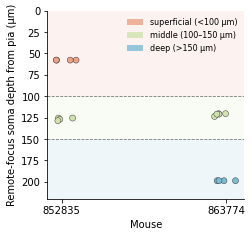

In [10]:
fig, ax = plt.subplots(figsize=(3.6, 3.4))

depth_upper = max(220, recorded_depths["soma_depth_um"].max() + 20)

ax.axhspan(0, 100, color=DEPTH_COLORS["<100 µm"], alpha=0.12, lw=0)
ax.axhspan(100, 150, color=DEPTH_COLORS["100–150 µm"], alpha=0.12, lw=0)
ax.axhspan(150, depth_upper, color=DEPTH_COLORS[">150 µm"], alpha=0.12, lw=0)

mice = list(pd.unique(recorded_depths["subject_id"]))
xpos = {mouse: i for i, mouse in enumerate(mice)}

rng = np.random.default_rng(8)

for mouse in mice:
    d = recorded_depths.loc[
        recorded_depths["subject_id"] == mouse
    ].copy()

    x = xpos[mouse] + rng.uniform(-0.09, 0.09, size=len(d))

    ax.scatter(
        x,
        d["soma_depth_um"],
        s=36,
        c=[DEPTH_COLORS[g] for g in d["depth_group"]],
        edgecolor="0.2",
        linewidth=0.45,
        zorder=3,
    )

for boundary in (100, 150):
    ax.axhline(boundary, color="0.45", lw=0.8, ls="--")

ax.set_xticks(range(len(mice)), [str(x) for x in mice])
ax.set_xlabel("Mouse")
ax.set_ylabel("Remote-focus soma depth from pia (µm)")
ax.set_ylim(depth_upper, 0)
ax.spines[["top", "right"]].set_visible(False)

handles = [
    Patch(
        facecolor=DEPTH_COLORS[g],
        edgecolor="none",
        alpha=0.8,
        label=f"{DEPTH_NAMES[g]} ({g})",
    )
    for g in DEPTH_GROUP_ORDER
]
ax.legend(handles=handles, frameon=False, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## SWC reconstruction Z depths

Soma depth is the median Z coordinate of SWC type-1 soma nodes. If a file has no type-1 node, the root node is used. These depths are not modified by the remote-focus conversion.

In [11]:
records = []

swc_files = sorted(SWC_DIR.rglob("*.swc"))
if not swc_files:
    raise FileNotFoundError(f"No .swc files found in:\n{SWC_DIR}")

for swc_path in swc_files:
    try:
        swc = pd.read_csv(
            swc_path,
            sep=r"\s+",
            comment="#",
            header=None,
            names=[
                "node_id", "type", "x", "y", "z", "radius", "parent_id",
            ],
        )
    except Exception as exc:
        print(f"Could not read {swc_path.name}: {exc}")
        continue

    for col in ["node_id", "type", "x", "y", "z", "radius", "parent_id"]:
        swc[col] = pd.to_numeric(swc[col], errors="coerce")

    swc = swc.dropna(subset=["z"])
    if swc.empty:
        print(f"Skipping {swc_path.name}: no valid Z coordinates")
        continue

    soma = swc[swc["type"] == 1]

    if not soma.empty:
        soma_z = float(soma["z"].median())
        soma_source = "type 1 soma"
    else:
        root = swc[swc["parent_id"] == -1]
        if root.empty:
            print(f"Skipping {swc_path.name}: no soma or root node")
            continue
        soma_z = float(root["z"].iloc[0])
        soma_source = "root fallback"

    records.append({
        "swc_file": swc_path.name,
        "soma_depth_um": soma_z,
        "soma_source": soma_source,
    })

soma_depths = pd.DataFrame(records)
if soma_depths.empty:
    raise RuntimeError("No usable SWC soma positions could be extracted.")

soma_depths["depth_group"] = soma_depths["soma_depth_um"].map(
    depth_group_from_um
)
soma_depths["depth_name"] = soma_depths["depth_group"].map(DEPTH_NAMES)

print(
    f"Reconstructed neurons: n = {len(soma_depths)}\n"
    f"Depth range: {soma_depths['soma_depth_um'].min():.1f}–"
    f"{soma_depths['soma_depth_um'].max():.1f} µm"
)
display(soma_depths.sort_values("soma_depth_um").reset_index(drop=True))

Reconstructed neurons: n = 16
Depth range: 36.0–277.9 µm


,swc_file,soma_depth_um,soma_source,depth_group,depth_name
0,slap2_super_stack_ch1-000.swc,36.000,root fallback,<100 µm,superficial
1,slap2_super_stack_ch1-001.swc,37.500,root fallback,<100 µm,superficial
2,slap2_super_stack_ch1-002.swc,64.500,root fallback,<100 µm,superficial
3,slap2_super_stack_ch1-003.swc,103.875,root fallback,100–150 µm,middle
4,slap2_super_stack_ch1-009.swc,111.500,root fallback,100–150 µm,middle
5,slap2_super_stack_ch1-014.swc,116.000,root fallback,100–150 µm,middle
6,slap2_super_stack_ch1-011.swc,123.000,root fallback,100–150 µm,middle
7,slap2_super_stack_ch1-013.swc,134.500,root fallback,100–150 µm,middle
8,slap2_super_stack_ch1-004.swc,135.750,root fallback,100–150 µm,middle
9,slap2_super_stack_ch1-007.swc,145.500,root fallback,100–150 µm,middle


## Combined remote-focus recorded + SWC depth distribution

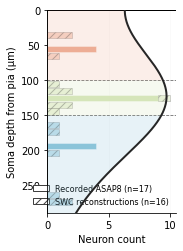

In [12]:
reconstructed_depths = soma_depths[["swc_file", "soma_depth_um"]].copy()
reconstructed_depths["source"] = "SWC reconstruction"
reconstructed_depths["neuron_id"] = reconstructed_depths["swc_file"].astype(str)

combined_depths = pd.concat(
    [
        recorded_depths[["neuron_id", "soma_depth_um", "source"]],
        reconstructed_depths[["neuron_id", "soma_depth_um", "source"]],
    ],
    ignore_index=True,
)

combined_depths["depth_group"] = combined_depths["soma_depth_um"].map(
    depth_group_from_um
)

depth_values = combined_depths["soma_depth_um"].to_numpy(float)
depth_max = max(
    220.0,
    np.ceil(np.nanmax(depth_values) / BIN_WIDTH_UM) * BIN_WIDTH_UM
    + BIN_WIDTH_UM,
)

bins = np.arange(0.0, depth_max + BIN_WIDTH_UM, BIN_WIDTH_UM)
centers = 0.5 * (bins[:-1] + bins[1:])

rec = recorded_depths["soma_depth_um"].to_numpy(float)
swc = reconstructed_depths["soma_depth_um"].to_numpy(float)

rec_counts, _ = np.histogram(rec, bins=bins)
swc_counts, _ = np.histogram(swc, bins=bins)

y_density = np.linspace(0.0, depth_max, 800)

if len(depth_values) >= 3 and np.nanstd(depth_values) > 0:
    reflected = np.concatenate([depth_values, -depth_values])
    kde = gaussian_kde(reflected, bw_method="scott")
    density = 2.0 * kde(y_density)
else:
    density = np.zeros_like(y_density)

fig, ax = plt.subplots(figsize=(2.7, 3.6))
ax_kde = ax.twiny()
ax_kde.patch.set_visible(False)

for r_n, s_n, center, lo, hi in zip(
    rec_counts, swc_counts, centers, bins[:-1], bins[1:]
):
    group = depth_group_from_um(center)
    color = DEPTH_COLORS[group]
    height = 0.86 * (hi - lo)

    if r_n:
        ax.barh(
            center,
            r_n,
            height=height,
            left=0,
            color=color,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.5,
            zorder=2,
        )

    if s_n:
        ax.barh(
            center,
            s_n,
            height=height,
            left=r_n,
            color=color,
            alpha=0.42,
            edgecolor="0.3",
            linewidth=0.5,
            hatch="///",
            zorder=3,
        )

for lo, hi, group in [
    (0, 100, "<100 µm"),
    (100, 150, "100–150 µm"),
    (150, depth_max, ">150 µm"),
]:
    mask = (y_density >= lo) & (y_density <= hi)
    ax_kde.fill_betweenx(
        y_density[mask],
        0,
        density[mask],
        color=DEPTH_COLORS[group],
        alpha=0.18,
        lw=0,
    )

ax_kde.plot(density, y_density, color="0.15", lw=2.0)

for boundary in (100, 150):
    ax.axhline(boundary, color="0.4", lw=0.8, ls="--", zorder=4)

ax.axhline(0, color="black", lw=1.0)

ax.set_ylim(depth_max, 0)
ax.set_xlabel("Neuron count")
ax.set_ylabel("Soma depth from pia (µm)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.10, lw=0.6)

ax_kde.set_xlim(
    0,
    max(float(np.nanmax(density)), 1e-9) * 1.08,
)
ax_kde.set_ylim(ax.get_ylim())
ax_kde.set_xticks([])
ax_kde.spines[["top", "bottom", "right"]].set_visible(False)

source_handles = [
    Patch(
        facecolor="white",
        edgecolor="0.25",
        label=f"Recorded ASAP8 (n={len(recorded_depths)})",
    ),
    Patch(
        facecolor="white",
        edgecolor="0.25",
        hatch="///",
        label=f"SWC reconstructions (n={len(reconstructed_depths)})",
    ),
]
ax.legend(
    handles=source_handles,
    frameon=False,
    fontsize=8,
    loc="lower right",
)

plt.tight_layout()
plt.show()
filen = 'depth_dist'
save_figure(fig,os.path.join(SAVEPATH,filen),formats=['.pdf'],dpi=300)

## Interpretation / objects to use downstream

For recorded ASAP8 neurons:

- `plane_depths` — one row per session × DMD; selected `.meta`, remote focus, configured pia reference, note depth, and discrepancy
- `roi_depths.depth_um` — session-specific remote-focus-derived depth for each ROI observation
- `recorded_depths.soma_depth_um` — median remote-focus depth across sessions for each longitudinal neuron
- `comparison_summary` — note-vs-remote discrepancy by mouse × DMD
- `changed_group` — neurons whose categorical depth group changes after calibration
- `recorded_depths.remote_depth_range_um` — across-session change in the recorded plane for each longitudinal neuron
- `soma_depths` — SWC soma Z depths
- `combined_depths` — remote-focus recorded neurons + SWC reconstructions

A DMD remote-focus value is still a **plane-level somatic depth estimate**, not a per-cell 3D centroid measurement within that imaging plane.

In [ ]:
# Rebuild DMD depths from the first SLAP2 remote-focus metadata acquisition
# for every session in VIP_SD_summary.xlsx.
#
# Convention:
#   BEFORE 809047_2025-10-03_16-13-46:
#       DMD1 pia = 0 µm
#       DMD2 pia = 0 µm
#
#   FROM 809047_2025-10-03_16-13-46 ONWARD:
#       DMD1 pia = -200 µm
#       DMD2 pia = -192.5 µm
#
# Output remains row-for-row aligned with the Excel sessions sheet.

from pathlib import Path
import re
import warnings

import h5py
import numpy as np
import pandas as pd
from IPython.display import display


BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")
SUMMARY_XLSX = BASE_PATH / "VIP_SD_summary.xlsx"

# First session using the newer remote-focus coordinate convention.
RF_CONVENTION_CHANGE = pd.Timestamp("2025-10-03 16:13:46")

OLD_PIA_RF_UM = {1: 0.0,    2: 0.0}
NEW_PIA_RF_UM = {1: -200.0, 2: -192.5}


def session_datetime(session_id, session_date=None):
    """Extract YYYY-MM-DD_HH-MM-SS from session_id; fall back to session_date."""
    m = re.search(
        r"(\d{4}-\d{2}-\d{2})_(\d{2})-(\d{2})-(\d{2})",
        str(session_id),
    )
    if m:
        date, hh, mm, ss = m.groups()
        return pd.Timestamp(f"{date} {hh}:{mm}:{ss}")

    if pd.notna(session_date):
        return pd.Timestamp(session_date)

    return pd.NaT


def acquisition_time(path):
    """HHMMSS embedded in a SLAP2 acquisition filename."""
    m = re.search(
        r"acquisition_(?:\d{8}_)?(\d{6})_DMD[12]\.meta$",
        Path(path).name,
        flags=re.I,
    )
    return int(m.group(1)) if m else 10**9


def find_first_meta(session_dir, dmd):
    """Find the first acquisition .meta for a DMD within a session."""
    session_dir = Path(session_dir)

    if not session_dir.exists():
        return None, 0

    # Prefer canonical acquisition filenames; broaden only if necessary.
    candidates = list(session_dir.rglob(f"acquisition*_DMD{dmd}.meta"))
    if not candidates:
        candidates = list(session_dir.rglob(f"*DMD{dmd}.meta"))

    if not candidates:
        return None, 0

    # Prefer the reorganized raw acquisition location if duplicates exist.
    dynamic = [
        p for p in candidates
        if any(part.lower() == "dynamic_data" for part in p.parts)
    ]
    if dynamic:
        candidates = dynamic

    candidates = sorted(
        set(candidates),
        key=lambda p: (
            acquisition_time(p),
            len(p.parts),
            str(p).lower(),
        ),
    )

    return candidates[0], len(candidates)


def read_remote_focus(meta_path):
    """Read remoteFocusPosition_um and cross-check ParsePlan/zs."""
    with h5py.File(meta_path, "r") as h5:
        if "remoteFocusPosition_um" not in h5:
            raise KeyError("remoteFocusPosition_um not found")

        remote = float(
            np.asarray(h5["remoteFocusPosition_um"][()]).squeeze()
        )

        parse_z = np.nan
        if "AcquisitionContainer/ParsePlan/zs" in h5:
            parse_z = float(
                np.asarray(
                    h5["AcquisitionContainer/ParsePlan/zs"][()]
                ).squeeze()
            )

    if np.isfinite(parse_z) and not np.isclose(remote, parse_z, atol=1e-3):
        warnings.warn(
            f"{Path(meta_path).name}: "
            f"remoteFocusPosition_um={remote:.3f}, "
            f"ParsePlan/zs={parse_z:.3f}"
        )

    return remote


# ---------------------------------------------------------------------
# Load session registry
# ---------------------------------------------------------------------

sessions_registry = pd.read_excel(SUMMARY_XLSX, sheet_name="sessions")

rows = []

for i, row in sessions_registry.iterrows():

    sid = str(row["session_id"])
    dt = session_datetime(sid, row.get("session_date"))

    # Determine which remote-focus coordinate convention applies.
    if pd.isna(dt):
        convention = "unknown"
        pia_by_dmd = None
    elif dt < RF_CONVENTION_CHANGE:
        convention = "pia zeroed at 0"
        pia_by_dmd = OLD_PIA_RF_UM
    else:
        convention = "pia at -200/-192.5"
        pia_by_dmd = NEW_PIA_RF_UM

    result = {
        "excel_row": i + 2,
        "session_id": sid,
        "subject_id": row.get("subject_id"),
        "session_date_time": dt,
        "session_type": row.get("session_type"),
        "indicator1": row.get("indicator1"),
        "session_dir": row.get("session_dir"),
        "rf_convention": convention,
        "old_dmd1_depth": row.get("dmd1_depth"),
        "old_dmd2_depth": row.get("dmd2_depth"),
    }

    for dmd in (1, 2):

        remote = np.nan
        depth = np.nan
        pia_rf = np.nan
        meta_path = None
        n_candidates = 0
        status = "missing"

        try:
            session_dir = row.get("session_dir")

            if pd.isna(dt):
                status = "could not determine session date"

            elif pd.isna(session_dir):
                status = "no session_dir"

            else:
                meta_path, n_candidates = find_first_meta(session_dir, dmd)

                if meta_path is None:
                    status = "no metadata"

                else:
                    remote = read_remote_focus(meta_path)
                    pia_rf = pia_by_dmd[dmd]

                    # Before convention change:
                    #     depth = remote - 0 = remote
                    #
                    # After convention change:
                    #     DMD1 depth = remote - (-200)
                    #     DMD2 depth = remote - (-192.5)
                    depth = remote - pia_rf

                    status = "ok"

        except Exception as exc:
            status = f"{type(exc).__name__}: {exc}"

        result.update({
            f"dmd{dmd}_remote_focus_um": remote,
            f"dmd{dmd}_pia_remote_focus_um": pia_rf,
            f"dmd{dmd}_corrected_depth_um": depth,
            f"dmd{dmd}_meta": str(meta_path) if meta_path else None,
            f"dmd{dmd}_n_meta": n_candidates,
            f"dmd{dmd}_status": status,
        })

    rows.append(result)


depth_updates = pd.DataFrame(rows)


# ---------------------------------------------------------------------
# Difference from existing handwritten registry depths
# ---------------------------------------------------------------------

for dmd in (1, 2):
    depth_updates[f"dmd{dmd}_delta_um"] = (
        pd.to_numeric(
            depth_updates[f"dmd{dmd}_corrected_depth_um"],
            errors="coerce",
        )
        - pd.to_numeric(
            depth_updates[f"old_dmd{dmd}_depth"],
            errors="coerce",
        )
    )


# ---------------------------------------------------------------------
# QC table
# ---------------------------------------------------------------------

display_cols = [
    "excel_row",
    "subject_id",
    "session_id",
    "session_date_time",
    "session_type",
    "rf_convention",

    "dmd1_remote_focus_um",
    "dmd1_pia_remote_focus_um",
    "old_dmd1_depth",
    "dmd1_corrected_depth_um",
    "dmd1_delta_um",

    "dmd2_remote_focus_um",
    "dmd2_pia_remote_focus_um",
    "old_dmd2_depth",
    "dmd2_corrected_depth_um",
    "dmd2_delta_um",

    "dmd1_status",
    "dmd2_status",
]

display(depth_updates[display_cols])

print(
    "\nSuccessful metadata reads:",
    f"DMD1: {depth_updates['dmd1_corrected_depth_um'].notna().sum()}/{len(depth_updates)} |",
    f"DMD2: {depth_updates['dmd2_corrected_depth_um'].notna().sum()}/{len(depth_updates)}"
)

print(
    "\nConvention counts:"
)
display(depth_updates["rf_convention"].value_counts(dropna=False).to_frame("n_sessions"))


# ---------------------------------------------------------------------
# Flag suspicious note-vs-metadata disagreements
# ---------------------------------------------------------------------

DISCREPANCY_THRESHOLD_UM = 15

suspicious = depth_updates[
    (depth_updates["dmd1_delta_um"].abs() > DISCREPANCY_THRESHOLD_UM)
    | (depth_updates["dmd2_delta_um"].abs() > DISCREPANCY_THRESHOLD_UM)
].copy()

print(
    f"\nSessions differing from notes by >{DISCREPANCY_THRESHOLD_UM} µm "
    f"on either DMD: {len(suspicious)}"
)

if len(suspicious):
    display(
        suspicious[[
            "excel_row", "session_id", "rf_convention",
            "old_dmd1_depth", "dmd1_corrected_depth_um", "dmd1_delta_um",
            "old_dmd2_depth", "dmd2_corrected_depth_um", "dmd2_delta_um",
        ]]
    )


# ---------------------------------------------------------------------
# Copy/paste-ready values, exact Excel row order
# ---------------------------------------------------------------------

corrected = depth_updates[
    ["dmd1_corrected_depth_um", "dmd2_corrected_depth_um"]
].round(2)

print("\nCOPY/PASTE INTO dmd1_depth + dmd2_depth:")
print(
    corrected.to_csv(
        sep="\t",
        index=False,
        header=False,
        na_rep="nan",
    )
)

dmd1_corrected_depths = corrected["dmd1_corrected_depth_um"].tolist()
dmd2_corrected_depths = corrected["dmd2_corrected_depth_um"].tolist()

In [ ]:
for item in corrected["dmd2_corrected_depth_um"].tolist():
    print(item)